## Linear Neural Unit with Least Squares

LNU ... Linear Neural Unit

$\tilde{\textbf{y}} =\textbf{X}^T\cdot\textbf{w}^T$

where $\tilde{\textbf{y}}$ is vector (1-D array) of all outputs of a neuron (in code it is as $y_n$)

$\textbf{w}^T=inv(\textbf{X}^T \cdot \textbf{X})\cdot \textbf{X}^T \cdot \textbf{y}
$


In the example bellow, output $y$ is calculated using two input variables $u_1$ and $u_2$ with their time embedding of 2 samples (i..e two samples back of $u_1$ and $u_2$).
So the feature vector is $\textbf{x}=[1 \ u_1(k-1) \  u_1(k-2) \ u_2(k-1) \ u_2(k-2)]$.
Linear neuron then calculates every single $y(k)$ as $y(k)=\textbf{w}\cdot\textbf{x}$ and for all of them as above.

In the example bellow, notice the data normalization and denormalizaton. Also, notice that the linear neuron can not learn the noise (beacuse the noise is a nonlinear phenomenom), and because the feature vector here corresponds to data behavior, then the trained linear neuron is able to learn proper behavior from noisy data (if we used nonlinear neuron, it will learn noise as well, which will be incorrect in this case)

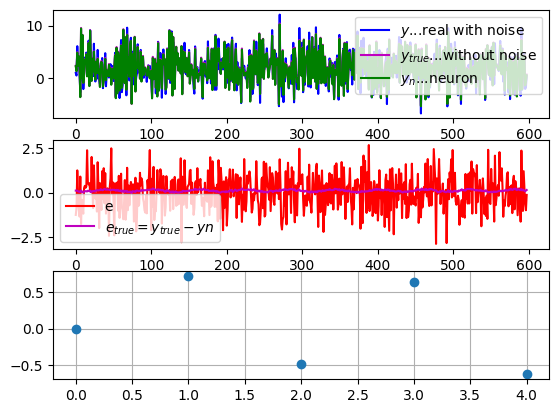

In [ ]:
#%matplotlib widget
from numpy import *
from matplotlib.pyplot import *
## measuring data
#N=100
nu1=2
nu2=2
ny=2
n=1+nu1+nu2

t=arange(0,60,.1)
N=len(t)
u1=sin(2*pi/6*t)
u2=random.randn(N)
y=zeros(N)
X=ones((N,n))
ytrue=zeros(N)
for k in range(2,N):
    ytrue[k]=2+3*u1[k-1]-2*u1[k-2]+2*u2[k-1]-2*u2[k-2]  # data behavior
    y[k]=ytrue[k]+random.randn()   # "measuring" real output with noise

u1=(u1-mean(u1))/std(u1)/3
u2=(u2-mean(u2))/std(u2)/3

meany=mean(y)
stdy=std(y)

y=(y-meany)/stdy/3

for k in range(2,N):
    #filling X matrix
    X[k,1]=u1[k-1]
    X[k,2]=u1[k-2]
    X[k,3]=u2[k-1]
    X[k,4]=u2[k-2]
#====LNU with Least Squares

X=X[2:,:]
y=y[2:]
ytrue=ytrue[2:]

w=dot(dot(linalg.inv(dot(X.T,X)),X.T),y)

yn=dot(X,w)   # neuron output

yn=yn*3*stdy+meany  # returning to original scale of data
y=y*3*stdy+meany

e=y-yn
etrue=ytrue-yn

figure()
subplot(311)
plot(y,'b',label="$y$...real with noise")
plot(ytrue,'m',label="$y_{true}$...without noise")
plot(yn,'g',label="$y_n$...neuron");legend()
subplot(312)
plot(e,'r',label="e")
plot(etrue,'m',label="$e_{true}=y_{true}-y{n}$");legend()
subplot(313)
plot(w,'o');grid()
show()


There are measured data of four control signals for propellers motors (crazy fly drone) and the batery status, i.e., voltage.

![image.png](attachment:422da8e6-229a-4aff-a2b7-a0c0c1093bd0.png)
(image adopted from https://www.bitcraze.io/products/old-products/crazyflie-2-0/)

## Assignment 1
Use data from "battery_motor_log_example1 (no time specified).xls" where we assume data are sampled with constant sampling (if sampling is not constant, you can not train a prediction model with constant prediction horizon, here one sample).
<ul>
    <li>
Apply Linear Neuron and Least Squares direct weight calculation (the simplest one) to predict the batery status. For the beginning, try time embedding be 2 for all input variables to your neuron. Apply also data normalization before training, divide data to training data and testing data to validate how your model works for batery status prediction <b style="color:blue;">[0.5 Points]</b>
   </li>
   <li>
       Compare in more detail neural output $y_n$ and real target $y$ and calculate the  Pearson's correlation coefficients of neuron output and target data (do it both for training and testing data) . <b style="color:blue;">[0.2 Points]</b>
   </li>
</ul>

## Assignment 2
<ul>
<li>
  Repeat the above <b>Assignment 1</b> for dataset in "battery_motor_log(time specified).csv". The reason is that the data might not be sampled with constant sampling, so you have to verify if the sampling is both constant and same for all data. If sampling is not constant, interpolate data so you get data with constant sampling (and repeat tasks from Assignment 1)   <b style="color:blue;">[1.2 Points]</b>
   </li>  <li>
   Carry out a study for increased time embeddings (1,2,3,4...?) in feature vector, and observe its effect on training accuracy and on testing accuracy, e.g., via Mean Square Error, or other error criterion.<b style="color:blue;">[0.5 Points]</b>
   </li>
</ul>




Assignment 1 - a) Apply Linear Neuron and Least Squares direct weight calculation (the simplest one) to predict the batery status.
 For the beginning, try time embedding be 2 for all input variables to your neuron. Apply also data normalization before training,
 divide data to training data and testing data to validate how your model works for batery status prediction.

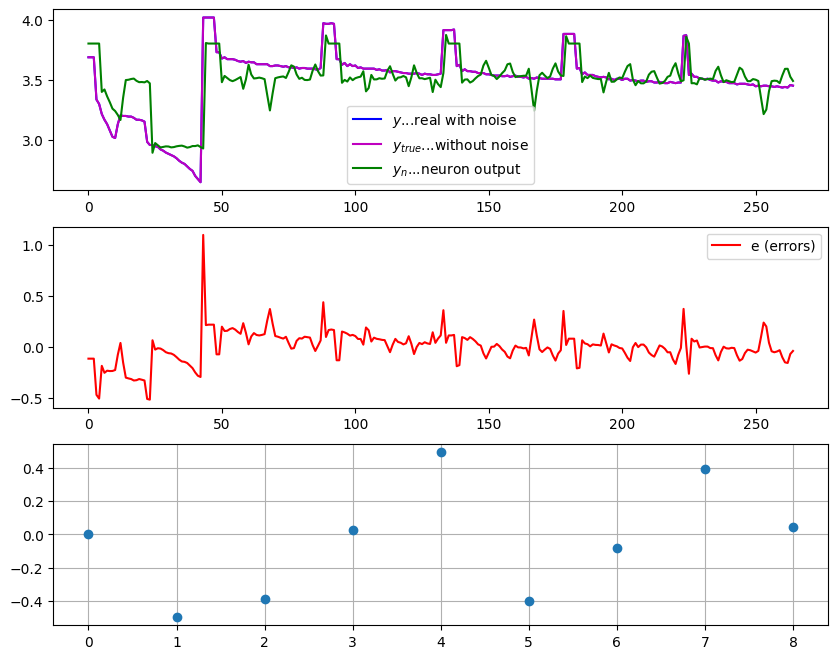

In [ ]:
# Importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load the dataset
data = pd.read_csv("/content/battery_motor_log_example1_(no_time_specified).csv")

# Extracting variables from the data
battery_voltage = data['Battery voltage (V)'].values
motor1_pwm = data['Motor1 PWM'].values
motor2_pwm = data['Motor2 PWM'].values
motor3_pwm = data['Motor3 PWM'].values
motor4_pwm = data['Motor4 PWM'].values

# Time embedding - lag 2 for all motor inputs
lag = 2
n = 1 + 4 * lag  # 4 motors, each with lag 2

N = len(battery_voltage)
X = np.ones((N, n))

# Normalize motor PWM signals and fill the matrix X
motors = [motor1_pwm, motor2_pwm, motor3_pwm, motor4_pwm]
for i, motor in enumerate(motors):
    motor_norm = (motor - np.mean(motor)) / np.std(motor) / 3  # Normalizing the motor signals
    for k in range(lag, N):
        X[k, i*lag+1] = motor_norm[k-1]
        X[k, i*lag+2] = motor_norm[k-2]

# Normalize the battery voltage
meany = np.mean(battery_voltage)
stdy = np.std(battery_voltage)
battery_voltage_norm = (battery_voltage - meany) / stdy / 3

# excluding the first lag rows
X = X[lag:, :]
y = battery_voltage_norm[lag:]

# Applying tthe Least Squares to calculate weights
w = np.dot(np.dot(np.linalg.inv(np.dot(X.T, X)), X.T), y)

# Neuron output (predicted battery status)
yn = np.dot(X, w)

# Rescale the predictions back to original battery voltage scale
yn = yn * 3 * stdy + meany
y_rescaled = y * 3 * stdy + meany

# Calculate errors
e = y_rescaled - yn

# Plot the results
plt.figure(figsize=(10, 8))

# Plot actual battery voltage, neuron output, and true output
plt.subplot(311)
plt.plot(y_rescaled, 'b', label="$y$...real with noise")
plt.plot(battery_voltage[lag:], 'm', label="$y_{true}$...without noise")
plt.plot(yn, 'g', label="$y_n$...neuron output")
plt.legend()

# Plot the errors
plt.subplot(312)
plt.plot(e, 'r', label="e (errors)")
plt.legend()

# Plot the weights
plt.subplot(313)
plt.plot(w, 'o')
plt.grid()
plt.show()


b) Compare in more detail neural output $y_n$ and real target $y$ and
    calculate the Pearson's correlation coefficients of neuron output and target data (do it both for training and testing data)


In [ ]:
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Applying Least Squares to calculate weights for training data
w = np.dot(np.dot(np.linalg.inv(np.dot(X_train.T, X_train)), X_train.T), y_train)

# Neuron output (predicted battery status) for training and testing data
yn_train = np.dot(X_train, w)
yn_test = np.dot(X_test, w)

# Rescaling the predictions back to original battery voltage scale
yn_train_rescaled = yn_train * 3 * stdy + meany
yn_test_rescaled = yn_test * 3 * stdy + meany

# Rescaling the actual values
y_train_rescaled = y_train * 3 * stdy + meany
y_test_rescaled = y_test * 3 * stdy + meany

# Calculating the Pearson's correlation coefficients
corr_train, _ = pearsonr(y_train_rescaled, yn_train_rescaled)
corr_test, _ = pearsonr(y_test_rescaled, yn_test_rescaled)

print(f"Pearson's correlation coefficient for training data: {corr_train:.4f}")
print(f"Pearson's correlation coefficient for testing data: {corr_test:.4f}")

Pearson's correlation coefficient for training data: 0.6554
Pearson's correlation coefficient for testing data: 0.8067


Pearson Correlation: The closer the values are to 1, the better the linear model is at predicting the battery voltage based on motor PWM signals.

Assignment 2: a) Repeat the above Assignment 1 for dataset in "battery_motor_log(time specified).csv". The reason is that the data might not be sampled
   with constant sampling, so you have to verify if the sampling is both constant and same for all data. If sampling is not constant,
    interpolate data so you get data with constant sampling (and repeat tasks from Assignment 1)

<ipython-input-20-41192da53e52>:14: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  data = pd.read_csv("/content/battery_motor_log(time_specified).csv",


Time differences between consecutive timestamps:
Datetime
2023-06-05 22:21:54.854200         NaN
2023-06-05 22:21:55.728460    0.874260
2023-06-05 22:21:55.761260    0.032800
2023-06-05 22:21:56.761302    1.000042
2023-06-05 22:21:56.764334    0.003032
                                ...   
2023-06-05 23:21:17.674298    1.071300
2023-06-05 23:21:17.575754   -0.098544
2023-06-05 23:21:18.600910    1.025156
2023-06-05 23:21:18.584630   -0.016280
2023-06-05 23:21:19.574078    0.989448
Name: Datetime, Length: 267, dtype: float64
Pearson's correlation coefficient for training data: 0.9967
Pearson's correlation coefficient for testing data: 0.9973


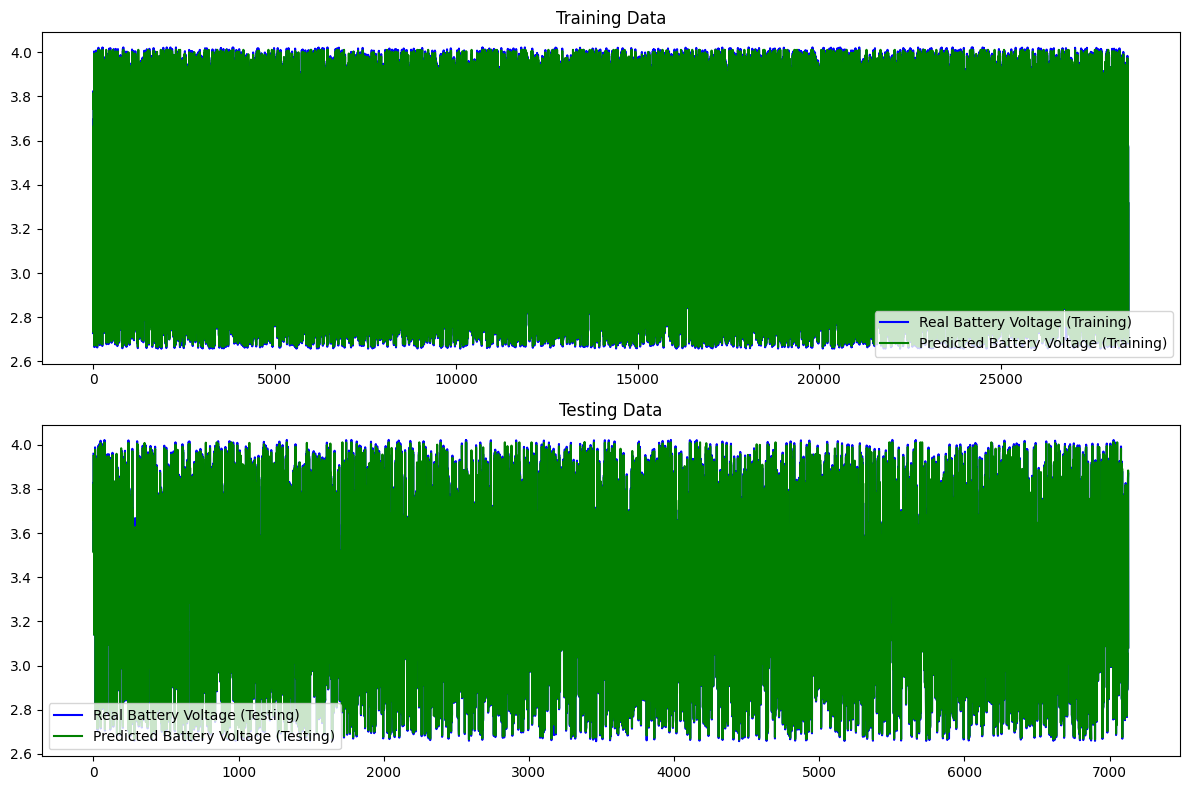

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr


# Load the dataset and parse dates
data = pd.read_csv("/content/battery_motor_log(time_specified).csv",
                   parse_dates={'Datetime': ['Date', 'Time']})


# Set the datetime column as the index
data.set_index('Datetime', inplace=True)

# Check the time difference between consecutive timestamps
time_diff = data.index.to_series().diff().dt.total_seconds()
print("Time differences between consecutive timestamps:")
print(time_diff)

# Resample data for a constant sampling rate (e.g., every 0.1 seconds)
data_resampled = data.resample('100ms').mean()  # Adjust the frequency as needed

# Interpolating the missing values
data_interpolated = data_resampled.interpolate(method='linear')
data_interpolated.reset_index(inplace=True)

battery_voltage = data_interpolated['Battery voltage (V)'].values
motor1_pwm = data_interpolated['Motor1 PWM'].values
motor2_pwm = data_interpolated['Motor2 PWM'].values
motor3_pwm = data_interpolated['Motor3 PWM'].values
motor4_pwm = data_interpolated['Motor4 PWM'].values

# Time embedding (lag 2 for all motor inputs)
lag = 2
n = 1 + 4 * lag  # 4 motors, each with lag 2

N = len(battery_voltage)
X = np.ones((N, n))

# Normalize motor PWM signals and fill the matrix X
motors = [motor1_pwm, motor2_pwm, motor3_pwm, motor4_pwm]
for i, motor in enumerate(motors):
    motor_norm = (motor - np.mean(motor)) / np.std(motor) / 3  # Normalizing the motor signals
    for k in range(lag, N):
        X[k, i*lag+1] = motor_norm[k-1]
        X[k, i*lag+2] = motor_norm[k-2]

# Normalize the battery voltage (target)
meany = np.mean(battery_voltage)
stdy = np.std(battery_voltage)
battery_voltage_norm = (battery_voltage - meany) / stdy / 3

# Slice the matrices to exclude the first lag rows
X = X[lag:, :]
y = battery_voltage_norm[lag:]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply Least Squares to calculate weights for training data
w = np.dot(np.dot(np.linalg.inv(np.dot(X_train.T, X_train)), X_train.T), y_train)

# Neuron output (predicted battery status) for training and testing data
yn_train = np.dot(X_train, w)
yn_test = np.dot(X_test, w)

# Rescale the predictions back to original battery voltage scale
yn_train_rescaled = yn_train * 3 * stdy + meany
yn_test_rescaled = yn_test * 3 * stdy + meany

# Rescale the actual values
y_train_rescaled = y_train * 3 * stdy + meany
y_test_rescaled = y_test * 3 * stdy + meany

# Calculate Pearson's correlation coefficients
corr_train, _ = pearsonr(y_train_rescaled, yn_train_rescaled)
corr_test, _ = pearsonr(y_test_rescaled, yn_test_rescaled)

# Print the correlation coefficients
print(f"Pearson's correlation coefficient for training data: {corr_train:.4f}")
print(f"Pearson's correlation coefficient for testing data: {corr_test:.4f}")


plt.figure(figsize=(12, 8))

# Plot training data
plt.subplot(2, 1, 1)
plt.plot(y_train_rescaled, 'b', label="Real Battery Voltage (Training)")
plt.plot(yn_train_rescaled, 'g', label="Predicted Battery Voltage (Training)")
plt.title("Training Data")
plt.legend()

# Plot testing data
plt.subplot(2, 1, 2)
plt.plot(y_test_rescaled, 'b', label="Real Battery Voltage (Testing)")
plt.plot(yn_test_rescaled, 'g', label="Predicted Battery Voltage (Testing)")
plt.title("Testing Data")
plt.legend()

plt.tight_layout()
plt.show()

Pearson Correlation: The closer the values are to 1, the better the linear model is at predicting the battery voltage based on motor PWM signals.

Testing with lag = 1...
Testing with lag = 2...
Testing with lag = 3...
Testing with lag = 4...
Testing with lag = 5...
Testing with lag = 6...
Testing with lag = 7...
Testing with lag = 8...
Testing with lag = 9...
Testing with lag = 10...
Testing with lag = 11...
Testing with lag = 12...
Testing with lag = 13...
Testing with lag = 14...


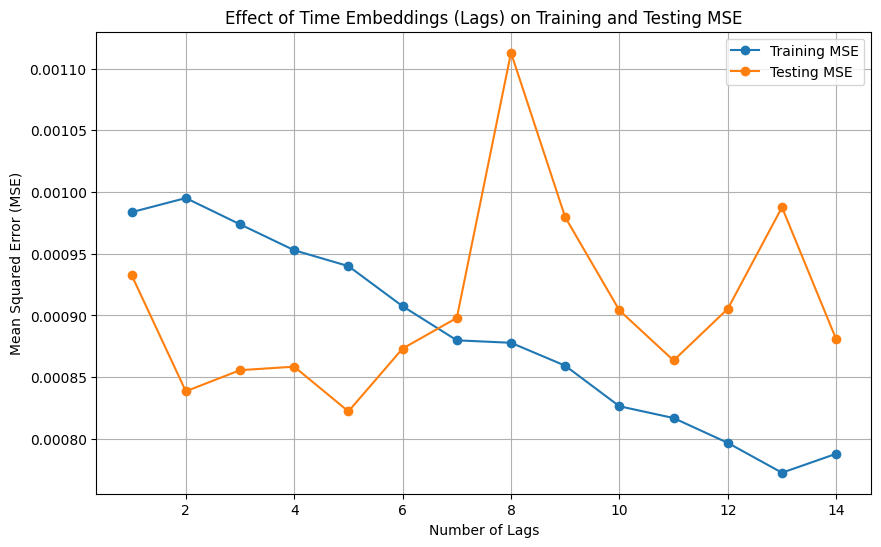

In [ ]:
# Function to create a feature matrix with given time lags
def create_feature_matrix(lag):
    N = len(battery_voltage)
    n = 1 + 4 * lag  # 4 motors, each with the given lag
    X = np.ones((N, n))

    for i, motor_norm in enumerate(normalized_motors):
        for k in range(lag, N):
            for l in range(1, lag+1):
                X[k, i*lag+l] = motor_norm[k-l]

    # Normalize the battery voltage (target)
    meany = np.mean(battery_voltage)
    stdy = np.std(battery_voltage)
    battery_voltage_norm = (battery_voltage - meany) / stdy / 3

    # Return feature matrix X and target battery voltage (normalized)
    return X[lag:, :], battery_voltage_norm[lag:], meany, stdy

# Range of time lags to test
lag_range = range(1, 15)  # Lags from 1 to 4

# Lists to store results
train_errors = []
test_errors = []

# Loop through the different lags and compute errors
for lag in lag_range:
    print(f"Testing with lag = {lag}...")

    # Create feature matrix and target vector
    X, y, meany, stdy = create_feature_matrix(lag)

    # Split into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Apply Least Squares to calculate weights for training data
    w = np.dot(np.dot(np.linalg.inv(np.dot(X_train.T, X_train)), X_train.T), y_train)

    # Neuron output (predicted battery status) for training and testing data
    yn_train = np.dot(X_train, w)
    yn_test = np.dot(X_test, w)

    # Rescale the predictions back to original battery voltage scale
    yn_train_rescaled = yn_train * 3 * stdy + meany
    yn_test_rescaled = yn_test * 3 * stdy + meany

    # Rescale the actual values
    y_train_rescaled = y_train * 3 * stdy + meany
    y_test_rescaled = y_test * 3 * stdy + meany

    # Calculate MSE for training and testing sets
    train_mse = mean_squared_error(y_train_rescaled, yn_train_rescaled)
    test_mse = mean_squared_error(y_test_rescaled, yn_test_rescaled)

    # Store the results
    train_errors.append(train_mse)
    test_errors.append(test_mse)

# Plot the MSE for training and testing sets as a function of lag
plt.figure(figsize=(10, 6))
plt.plot(lag_range, train_errors, label='Training MSE', marker='o')
plt.plot(lag_range, test_errors, label='Testing MSE', marker='o')
plt.xlabel('Number of Lags')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Effect of Time Embeddings (Lags) on Training and Testing MSE')
plt.legend()
plt.grid(True)
plt.show()


Training Accuracy: Increasing lags often leads to better fitting on the training set, which lowers the training MSE.

Testing Accuracy: For the testing set, we can observe a certain point where the performance improves and then starts to deteriorate due to overfitting. Overfitting occurs when the model becomes too complex and fits the noise in the training data rather than capturing the true underlying pattern.

## Notice  <b style="color:red">(IMPORTANT!!!)</b>:
<ul>
<li>
It is recommended that you implement your solution in your code (as derived and shown at the lecture and in the above example).
</li><li>
You can also use any existing librabry or use chatGPT to help you solve it (in that case, report/copy your discussion with chatGPT and summarize your evaluation of it and explain the method that you used if it is other than as it was at lectures.
</li><li>
Importantly, if you are not able to explain your solution and principles of the methods that you used to solve your assignment, your points will be discarded at the final exam.
</li><li>
In other words, you have to understand the principles of the methods that you apply (yourself or with SciKit, or,... , or with chatGPT), and be able to explain it at the exam.
</li>
</ul>

## Project or Thesis Options:

If you like this application and if you are interested in investigating machine learning based prediction models for this drone application, pls. let me know, a larger project or thesis is possible on this topic.